# EDA for results

In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_json('../figure3/results.jsonl', lines=True)
df.head()

results_df = pd.read_json("scaleup_condition_changes_20251128_112530_results.jsonl", lines=True)


ModuleNotFoundError: No module named 'pandas'

In [102]:
grouped_by_verifier_category = results_df.groupby('verifier_category')

for verifier_category, dfg in grouped_by_verifier_category:
    for i,k in dfg.iterrows():
        if k["verifier_agree"] == False:
            if k["primary_category"] == k["verifier_category"]:
                continue
            print(k["primary_category"], " >> ", k["verifier_category"])
            lookup = k["row_index"]

            line = df.iloc[lookup]

            print(line["Problem_Description"])

            print(line["Solution_Description"])
            print(k["verifier_comment"])
            print()


continuous_process_intensification  >>  batch_to_flow_or_flow_process_implementation
Batch‑mode anion‑exchange chromatography of the siRNA sense strand gave a modest 80 % step‑yield and required labor‑intensive fractionation, mock‑pool analysis and occasional re‑chromatography of side‑cuts.  The process also consumed a relatively large amount of buffer and required a specialized twin‑column hardware platform that is not widely available on‑site.
The authors switched to a continuous twin‑column MCSGP process (new route/purification) that internally recycles low‑purity side‑cuts, eliminating the need for separate re‑chromatography.  The method uses an in‑line dilution buffer (solvent change) to lower modifier concentration and promote readsorption during recycling.  Parallel loading, washing and regeneration steps are performed on the second column while the first column elutes (mass‑transfer/mixing control), reducing overall cycle time.  Process parameters (gradient, flow‑rates, buffer 

In [103]:
cat_count = {}
for i,k in results_df.iterrows():
    vc = k["verifier_category"]
    if vc not in cat_count:
        cat_count[vc] = {}
    vconf = k["verifier_confidence"]
    if vconf not in cat_count[vc]:
        cat_count[vc][vconf] = 0
    cat_count[vc][vconf] += 1

for vc in cat_count:
    print(vc)
    for vconf in cat_count[vc]:
        print(vconf, cat_count[vc][vconf])

change_of_reductant_or_reduction_protocol
high 69
optimization_of_peptide_coupling_or_amidation
high 36
solvent_change_to_reduce_side_products
high 43
medium 1
introduction_of_additive_to_enable_reaction
high 38
solvent_change_for_reactivity
high 29
change_of_catalyst_or_ligand_identity
high 80
quench_or_scavenger_addition_optimization
high 48
solvent_change_for_solubility
high 41
medium 1
reagent_change_to_reduce_waste_or_increase_green_score
high 69
medium 2
crystallization_solvent_or_antisolvent_optimization
high 108
entirely_new_route_or_step_replacement
high 276
medium 4
thermal_runaway_mitigation_or_quench_safety_modification
high 86
hold_time_or_residence_time_optimization
medium 1
high 43
change_of_base
high 182
improved_impurity_purge_or_byproduct_control
high 113
medium 1
improved_quench_or_neutralization
high 52
improved_in_process_control_or_analytical_method
high 140
medium 3
crystallization_nucleation_or_seed_control
high 36
medium 1
optimization_of_oxygen_or_gas_enriched

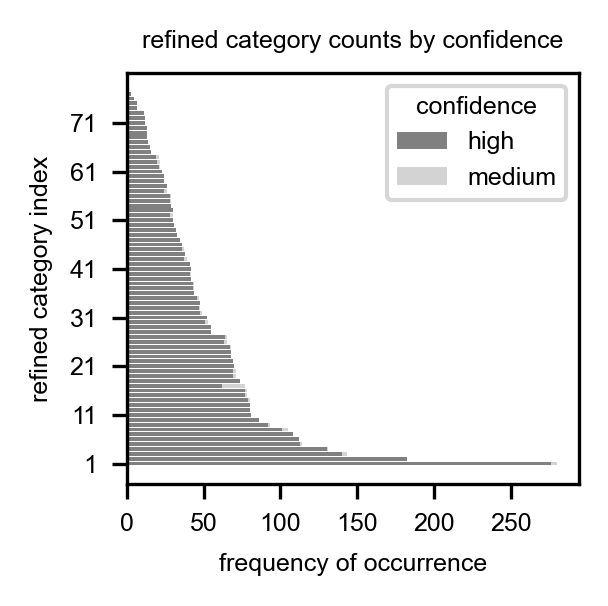

In [384]:
import pandas as pd
import matplotlib.pyplot as plt

# fontsize 6 arial
plt.rcParams['font.size'] = 6
plt.rcParams['font.family'] = 'Arial'

# 1) Build DataFrame from cat_count
# conf_levels = ["low", "medium", "high"]  # enforce ordering
conf_levels = ["high", "medium"]  # enforce ordering

cats = list(cat_count.keys())

data = {conf: [] for conf in conf_levels}
for cat in cats:
    conf_counts = cat_count[cat]
    for conf in conf_levels:
        data[conf].append(conf_counts.get(conf, 0))

plot_df = pd.DataFrame(data, index=cats)

# 2) Sort by total frequency (descending)
totals = plot_df.sum(axis=1)
plot_df = plot_df.loc[totals.sort_values(ascending=False).index]

# 3) Numeric x positions
x = range(len(plot_df))

fig, ax = plt.subplots(figsize=(2.01, 2), dpi=300)

# Black/grey palette and hatch patterns for each layer
colors = ["grey","lightgray","black"]

bottom = None
for i, conf in enumerate(conf_levels):
    values = plot_df[conf].values
    ax.barh(
        x,
        values,
        left=None if bottom is None else bottom.values,
        label=conf,
        color=colors[i],
        # edgecolor="black",
    )
    if bottom is None:
        bottom = plot_df[conf].copy()
    else:
        bottom += plot_df[conf]

ax.set_ylabel("refined category index")
ax.set_xlabel("frequency of occurrence")
ax.set_title("refined category counts by confidence", fontsize=6)

# Use 1–N x labels
ax.set_yticks(range(0, len(x), 10))
ax.set_yticklabels([str(i+1) for i in x if i % 10 == 0])

ax.legend(title="confidence")
plt.tight_layout()
# plt.show()
plt.savefig("refined_category_counts_by_confidence.png", dpi=300, pad_inches=0.01, bbox_inches="tight")

In [ ]:
import json
import pandas as pd
import plotly.graph_objects as go

# ---------------------------------------------------------------------
# 1. Ontology definition (Level 1 → Level 2 → Level 3 / leaf categories)
# ---------------------------------------------------------------------

ONTOLOGY = {
    "Chemical_Conditions": {
        "Reagents_Catalysts": [
            "change_of_primary_reagent",
            "change_of_oxidant_or_oxidation_protocol",
            "change_of_reductant_or_reduction_protocol",
            "change_of_catalyst_or_ligand_identity",
            "optimization_of_catalyst_loading",
            "replacement_of_unstable_or_impure_reagent",
            "replacement_of_costly_or_low_purity_reagent",
            "reagent_change_to_reduce_waste_or_increase_green_score",
        ],
        "Acid_Base_pH": [
            "change_of_base",
            "change_of_acid",
            "optimization_of_pH_or_buffer_conditions",
            "optimization_of_acid_or_base_stoichiometry",
        ],
        "Solvent_Phase": [
            "solvent_change_for_reactivity",
            "solvent_change_for_solubility",
            "solvent_change_for_safety_or_green_chemistry",
            "solvent_change_to_reduce_side_products",
            "solvent_system_optimization_or_cosolvent_addition",
            "phase_behavior_or_biphasic_system_optimization",
        ],
        "Additives": [
            "introduction_of_additive_to_enable_reaction",
            "introduction_of_additive_to_improve_selectivity",
            "quench_or_scavenger_addition_optimization",
            "removal_or_simplification_of_additives",
        ],
        "Stoichiometry_Kinetics": [
            "optimization_of_reagent_stoichiometry",
            "change_of_addition_order_or_feed_profile",
            "temperature_setpoint_or_temperature_ramp_optimization",
            "pressure_or_gas_headspace_optimization",
            "hold_time_or_residence_time_optimization",
        ],
        "ProtectingGroups_Substrate": [
            "protecting_group_change_or_removal",
            "substrate_scaffold_change",
            "functional_group_change_to_avoid_instability",
            "substrate_change_to_improve_purification",
            "route_change_to_rescue_selectivity_or_stability",
        ],
    },
    "Workup_and_Purification": {
        "Extraction_and_Workup": [
            "improved_extraction_or_phase_separation",
            "improved_quench_or_neutralization",
            "improved_impurity_purge_or_byproduct_control",
            "filtration_or_solid_liquid_separation_improvement",
            "centrifugation_or_clarification_optimization",
            "drying_or_isolation_process_optimization",
        ],
        "Crystallization": [
            "crystallization_solvent_or_antisolvent_optimization",
            "crystallization_nucleation_or_seed_control",
            "polymorph_or_solid_form_management",
        ],
        "Impurity_and_QC": [
            "feedstock_or_supplier_variability_management",
            "tolerance_of_reagent_or_feed_impurities",
            "improved_in_process_control_or_analytical_method",
            "adjustment_of_release_criteria_or_quality_specifications",
        ],
    },
    "Specialized_Chemistries": {
        "Halogenation_Fluorination": [
            "optimization_of_halogenation_protocol",
            "optimization_of_fluorination_protocol",
            "optimization_of_chlorination_or_activation_protocol",
        ],
        "Coupling_Hydrogenolysis_Acylation": [
            "optimization_of_peptide_coupling_or_amidation",
            "optimization_of_reductive_or_hydrogenolysis_protocol",
            "optimization_of_formylation_or_acylation_protocol",
        ],
        "Biocatalysis": [
            "biocatalytic_or_enzymatic_route_change_or_optimization",
        ],
    },
    "Process_Engineering": {
        "Reactor_and_Hardware": [
            "reactor_scale_change_without_changing_chemistry",
            "reactor_geometry_or_hold_up_optimization",
            "improved_mixing_or_impeller_design",
            "improved_heat_transfer_or_temperature_control_hardware",
            "improved_photochemical_reactor_or_light_delivery",
            "improved_electrochemical_reactor_or_electrode_system",
            "custom_or_novel_reactor_design_to_reduce_cost_or_risk",
        ],
        "Flow_and_Solids": [
            "batch_to_flow_or_flow_process_implementation",
            "packed_bed_or_fixed_bed_optimization",
            "clogging_or_fouling_mitigation",
            "slurry_handling_or_particle_size_optimization",
            "gas_evolution_or_mass_transfer_management",
            "continuous_process_intensification",
        ],
        "Atmosphere_and_Safety": [
            "optimization_of_inert_atmosphere_or_deoxygenation",
            "optimization_of_oxygen_or_gas_enriched_environment",
            "condition_change_to_reduce_or_remove_process_hazard",
            "thermal_runaway_mitigation_or_quench_safety_modification",
        ],
    },
    "Strategy_and_Optimization": {
        "Screening_Modeling": [
            "reaction_condition_screening_or_HTE",
            "design_of_experiments_or_multivariate_optimization",
            "kinetic_or_mechanistic_modeling_guided_change",
            "process_modeling_or_digital_twin_guided_change",
        ],
        "Route_Design": [
            "step_reordering_or_telescope_strategy",
            "entirely_new_route_or_step_replacement",
        ],
        "Fallback": [
            "insufficient_information_to_classify",
            "other",
        ],
    },
}

# Build a lookup: leaf category -> (L1, L2)
cat_to_L1L2 = {}
for L1, subdict in ONTOLOGY.items():
    for L2, leaf_list in subdict.items():
        for leaf in leaf_list:
            if leaf in cat_to_L1L2:
                raise ValueError(f"Leaf category {leaf} appears in multiple L2 groups.")
            cat_to_L1L2[leaf] = (L1, L2)

# ---------------------------------------------------------------------
# 2. Load dataset
# ---------------------------------------------------------------------

# Path to your results file
results_path = "scaleup_condition_changes_20251128_112530_results.jsonl"

df = pd.read_json(results_path, lines=True)

# Use verifier_category as the final leaf label
if "verifier_category" not in df.columns:
    raise ValueError("Expected 'verifier_category' column in the results file.")

# Count occurrences per leaf category
leaf_counts = df["verifier_category"].value_counts().to_dict()

# Sanity check: warn on any categories not in ontology
unknown_cats = sorted(set(leaf_counts.keys()) - set(cat_to_L1L2.keys()))
if unknown_cats:
    print("Warning: categories not found in ontology:", unknown_cats)

# ---------------------------------------------------------------------
# 3. Build aggregated counts for edges:
#    L1 -> L2 and L2 -> Leaf
# ---------------------------------------------------------------------

# We’ll only include leaf categories that actually appear in the data
L1_L2_counts = {}   # (L1, L2) -> count
L2_leaf_counts = {} # (L2, leaf) -> count

for leaf, count in leaf_counts.items():
    if leaf not in cat_to_L1L2:
        # ignore unknown categories; you could also bucket them to a special node if desired
        continue
    L1, L2 = cat_to_L1L2[leaf]

    # L1-L2 aggregation
    L1_L2_counts[(L1, L2)] = L1_L2_counts.get((L1, L2), 0) + count
    # L2-leaf aggregation
    L2_leaf_counts[(L2, leaf)] = L2_leaf_counts.get((L2, leaf), 0) + count

# ---------------------------------------------------------------------
# 4. Build Sankey nodes and links
#    Nodes: all L1, all L2, all used leaf categories
#    Links: L1->L2 (aggregated), L2->Leaf (aggregated)
# ---------------------------------------------------------------------

node_labels = []
node_index = {}

def add_node(label: str) -> int:
    """Add a node label if not already present and return its index."""
    if label not in node_index:
        node_index[label] = len(node_labels)
        node_labels.append(label)
    return node_index[label]

# Add L1 nodes
for L1 in ONTOLOGY.keys():
    add_node(L1)

# Add L2 nodes that actually have counts
used_L2 = set(L2 for (L1, L2) in L1_L2_counts.keys())
for L2 in used_L2:
    add_node(L2)

# Add leaf nodes that actually appear
used_leaf = set(leaf for (L2, leaf) in L2_leaf_counts.keys())
for leaf in used_leaf:
    add_node(leaf)

# Build links: L1 -> L2
source_indices = []
target_indices = []
values = []

for (L1, L2), count in L1_L2_counts.items():
    s = node_index[L1]
    t = node_index[L2]
    source_indices.append(s)
    target_indices.append(t)
    values.append(count)

# Build links: L2 -> leaf
for (L2, leaf), count in L2_leaf_counts.items():
    s = node_index[L2]
    t = node_index[leaf]
    source_indices.append(s)
    target_indices.append(t)
    values.append(count)

# ---------------------------------------------------------------------
# 5. Create the Sankey figure (you can run this to display it)
# ---------------------------------------------------------------------

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=15,
                thickness=20,
                label=node_labels,
                # You can customize these; for now leave default colors
            ),
            link=dict(
                source=source_indices,
                target=target_indices,
                value=values,
            ),
        )
    ]
)

fig.update_layout(
    title_text="Scale-up Problem/Solution Ontology Sankey (L1 → L2 → Category)",
    font=dict(size=10),
)

# To actually view this in a notebook, run:
# fig.show()

# Or to save:
# fig.write_html("scaleup_sankey.html")

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# -------------------------------------------------------------
# 1. Build leaf counts from verifier_category
# -------------------------------------------------------------
if "verifier_category" not in df.columns:
    raise ValueError("Expected 'verifier_category' column in df.")

leaf_counts = df["verifier_category"].value_counts().to_dict()

# Map leaf -> (L1, L2) from ontology
cat_to_L1L2 = {}
for L1, subdict in ONTOLOGY.items():
    for L2, leaf_list in subdict.items():
        for leaf in leaf_list:
            if leaf in cat_to_L1L2:
                raise ValueError(f"Leaf category {leaf} appears in multiple L2 groups.")
            cat_to_L1L2[leaf] = (L1, L2)

# Keep only leaves that exist in ontology
leaf_counts = {leaf: cnt for leaf, cnt in leaf_counts.items() if leaf in cat_to_L1L2}

# -------------------------------------------------------------
# 2. Sort leaves by frequency and assign numeric indices
# -------------------------------------------------------------
sorted_leaves = sorted(leaf_counts.keys(), key=lambda c: leaf_counts[c], reverse=True)
leaf_to_index = {leaf: i + 1 for i, leaf in enumerate(sorted_leaves)}  # 1..N

leaf_mapping_df = pd.DataFrame(
    {
        "index": [leaf_to_index[leaf] for leaf in sorted_leaves],
        "category": sorted_leaves,
        "count": [leaf_counts[leaf] for leaf in sorted_leaves],
    }
).sort_values("index")
# Optional: leaf_mapping_df.to_csv("leaf_index_mapping.csv", index=False)
# print(leaf_to_index)
# -------------------------------------------------------------
# 3. Aggregate counts for L1->L2 and L2->leaf
# -------------------------------------------------------------
L1_L2_counts = {}   # (L1, L2) -> count
L2_leaf_counts = {} # (L2, leaf) -> count
L1_counts = {}
L2_counts = {}
for leaf, count in leaf_counts.items():
    L1, L2 = cat_to_L1L2[leaf]
    L1_L2_counts[(L1, L2)] = L1_L2_counts.get((L1, L2), 0) + count
    L1_counts[L1] = L1_counts.get(L1, 0) + count
    L2_counts[L2] = L2_counts.get(L2, 0) + count
    L2_leaf_counts[(L2, leaf)] = L2_leaf_counts.get((L2, leaf), 0) + count

# -------------------------------------------------------------
# 4. Build node list and links
#    Nodes: L1, L2, leaf_index (1..N)
# -------------------------------------------------------------
node_labels = []      # what is rendered
node_ids = []         # internal IDs, parallel to node_labels
node_hover = []       # custom hover text

node_index = {}

def add_node(node_id: str, label: str, hover: str) -> int:
    if node_id not in node_index:
        node_index[node_id] = len(node_labels)
        node_ids.append(node_id)
        node_labels.append(label)
        node_hover.append(hover)
    return node_index[node_id]

# L1 nodes
for L1 in ONTOLOGY.keys():
    label = L1 + " (" + str(L1_counts[L1]) + ")"
    add_node(L1, label, L1)

# L2 nodes (only those used)
used_L2 = {L2 for (L1, L2) in L1_L2_counts.keys()}
for L2 in used_L2:
    label = L2 + " (" + str(L2_counts[L2]) + ")"
    add_node(L2, label, L2)

# Leaf nodes: numeric label, full name only in hover
for leaf in sorted_leaves:
    idx = leaf_to_index[leaf]
    node_id = f"leaf_{idx}"
    label = str(idx)+". "+leaf + " (" + str(leaf_counts[leaf]) + ")"          # what’s printed
    hover = f"{idx}: {leaf}"   # what shows on hover
    add_node(node_id, label, hover)

# Links
source_indices = []
target_indices = []
values = []

# L1 -> L2
for (L1, L2), count in L1_L2_counts.items():
    s = node_index[L1]
    t = node_index[L2]
    source_indices.append(s)
    target_indices.append(t)
    values.append(count)

# L2 -> leaf
for (L2, leaf), count in L2_leaf_counts.items():
    idx = leaf_to_index[leaf]
    node_id = f"leaf_{idx}"
    s = node_index[L2]
    t = node_index[node_id]
    source_indices.append(s)
    target_indices.append(t)
    values.append(count)

# -------------------------------------------------------------
# 5. Monochrome styling + manuscript sizing
#    7" x 9" at 300 dpi → 2100 x 2700 px
#    6 pt font → 6/72 inch → at 300 dpi ≈ 25 px
# -------------------------------------------------------------
dpi = 300/5
width_px = int(3 * dpi)
height_px = int(6 * dpi)
font_size_px = int(6 / 72 * dpi)/5  # ≈ 25

max_val = max(values) if values else 1

def node_color(node_id: str) -> str:
    # L1
    if node_id in ONTOLOGY:
        return "black"
    # L2
    if any(node_id in sub for sub in ONTOLOGY.values()):
        return "#555555"
    # leaves
    return "#AAAAAA"

node_colors = [node_color(nid) for nid in node_ids]

def link_color(v: float) -> str:
    intensity = max(40, 180 - int(140 * (v / max_val)))
    return f"rgba({intensity},{intensity},{intensity},0.7)"

link_colors = [link_color(v) for v in values]

# -------------------------------------------------------------
# 6. Build and save the figure
# -------------------------------------------------------------
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=10,
                thickness=15,
                line=dict(color="black", width=0.5),
                label=node_labels,
                color=node_colors,
                customdata=node_hover,
                hovertemplate="%{customdata}<extra></extra>",
            ),
            link=dict(
                source=source_indices,
                target=target_indices,
                value=values,
                color=link_colors,
                hovertemplate="Count: %{value}<extra></extra>",
            ),
        )
    ]
)

fig.update_layout(
    title=dict(
        text="Scale-up Ontology Flow (L1 → L2 → Leaf Index)",
        font=dict(size=font_size_px, color="black"),
        x=0.5,
        xanchor="center",
    ),
    font=dict(size=font_size_px, color="black"),
    plot_bgcolor="white",
    paper_bgcolor="white",
    width=width_px,
    height=height_px,
    margin=dict(l=30, r=30, t=60, b=30),
)
fig.write_image("scaleup_sankey_indexed2.svg", width=width_px, height=height_px, scale=2)

print("Saved: scaleup_sankey_indexed.png and scaleup_sankey_indexed.svg")
print("Leaf index mapping is in leaf_mapping_df (for caption / SI).")

KeyboardInterrupt: 

In [ ]:
from llm_evaluation_helper_v2 import get_shared_client
from llm_compound_classifier import resolve_smiles_from_name, extract_compound_replacements
client=get_shared_client()

costly_low_purity_outs = []
green_score_outs = []
change_of_base_outs = []
for ii,jj in results_df.iterrows():
    lookup = jj["row_index"]
    line = df.iloc[lookup]
    if jj["verifier_category"] == "replacement_of_costly_or_low_purity_reagent":
        print(line["Problem_Description"])
        print(line["Solution_Description"])
        out = extract_compound_replacements(line["Problem_Description"], line["Solution_Description"], client=client)
        print(out)
        costly_low_purity_outs.append(out)
        print()

    if jj["verifier_category"] == "change_of_base":
        print(line["Problem_Description"])
        print(line["Solution_Description"])
        out = extract_compound_replacements(line["Problem_Description"], line["Solution_Description"], client=client)
        print(out)
        change_of_base_outs.append(out)
        print()
        # break

    if jj["verifier_category"] == "reagent_change_to_reduce_waste_or_increase_green_score":
        print(line["Problem_Description"])
        print(line["Solution_Description"])
        out = extract_compound_replacements(line["Problem_Description"], line["Solution_Description"], client=client)
        print(out)
        green_score_outs.append(out)
        print()
    #     # break

The bromination in the legacy routes used sodium hydride, a pyrophoric reagent, and the N‑methylation employed dimethyl sulfate, a highly toxic and potentially carcinogenic reagent, both unsuitable for large‑scale production.
The bromination was replaced with the NaBr‑NaClO system, which is inexpensive and safer.  N‑Methylation was performed with paraformaldehyde (a low‑toxicity solid) catalyzed by Pt/C, eliminating the need for dimethyl sulfate.
problematic_compounds=[NamedCompound(name='sodium hydride', smiles='[H-].[Na+]'), NamedCompound(name='dimethyl sulfate', smiles='COS(=O)(=O)OC')] replacement_compounds=[NamedCompound(name='NaBr‑NaClO system', smiles=None), NamedCompound(name='paraformaldehyde', smiles='C=O'), NamedCompound(name='Pt/C', smiles=None)] pairs=[ReplacementPair(problematic=NamedCompound(name='sodium hydride', smiles=None), replacement=NamedCompound(name='NaBr‑NaClO system', smiles=None)), ReplacementPair(problematic=NamedCompound(name='dimethyl sulfate', smiles=None

In [ ]:

import dill
subproblems = {"change_of_base": change_of_base_outs, "green_score": green_score_outs, "costly_low_purity": costly_low_purity_outs}

dill.dump(subproblems, open("subproblems.pkl", "wb"))


In [493]:
for ii,jj in results_df.iterrows():
    lookup = jj["row_index"]
    line = df.iloc[lookup]
    # if jj["verifier_category"] == "replacement_of_costly_or_low_purity_reagent":
    #     print(line["Problem_Description"])
    #     print(line["Solution_Description"])
    #     print()

    # if jj["verifier_category"] == "change_of_base":
    #     if "NaH" in line["Problem_Description"] or "sodium hydride" in line["Problem_Description"] \
    #     or "NaH" in line["Solution_Description"] or "sodium hydride" in line["Solution_Description"]:
    #         print(line["Problem_Description"])
    #         print(line["Solution_Description"])
    #         print(line["Paper URL"])
    #         print()
    # if jj["verifier_category"] == "change_of_base":
        # if "pyridine" in line["Problem_Description"] or "Na2CO3" in line["Problem_Description"]  or "sodium carbonate" in line["Problem_Description"] \
        # or "pyridine" in line["Solution_Description"] or "Na2CO3" in line["Solution_Description"] or "sodium carbonate" in line["Solution_Description"] \
        # if ("Na" in line["Solution_Description"] and "CO" in line["Solution_Description"]):
        # if "pyridine" in line["Problem_Description"] or "Na₂CO₃" in line["Solution_Description"]:
        #     print(line["Problem_Description"])
        #     print(line["Solution_Description"])
        #     print(line["Paper URL"])
        #     print()
        # break

    if jj["verifier_category"] == "reagent_change_to_reduce_waste_or_increase_green_score":
        if "1,1'-carbonyldiimidazole" in line["Solution_Description"] or "toluene" in line["Solution_Description"]:
            print(line["Problem_Description"])
            print(line["Solution_Description"])
            print(line["Paper URL"])
            print()
    #     print(line["Problem_Description"])
    #     print(line["Solution_Description"])
    #     print()

The literature approach to fragment‑A (compound 2) uses isocyanates or phosgene, which are highly toxic, unstable and difficult to handle on scale.
A safer, process‑friendly route was developed that couples tert‑butylamine with CDI in toluene to give the activated intermediate, followed by coupling with tert‑leucine to give 2 in 82 % isolated yield and >99 % purity.
https://doi.org/10.1021/op500065t

The original route employed methyl iodide as the methylating reagent for compound 4, which is a known carcinogen and therefore unsuitable for large‑scale manufacturing.
Methyl p‑toluenesulfonate was substituted for methyl iodide as the methylating agent. The reaction in acetonitrile at 82 °C for 24 h cleanly gave the tosylate salt 10, which precipitated on addition of isopropyl acetate and could be isolated by filtration on kilogram scale (93 % yield, 99 % purity).
https://doi.org/10.1021/op5003402

Transfer hydrogenation with cyclohexene generates benzene as a by‑product, a known carcinog

In [ ]:

smiles_map = {
    "Bredereck’s reagent": "O=P(Cl)(Cl)Cl",   # mixture of DMF + POCl3 (not a single compound)
    "HOSO₂Cl": "OS(=O)(=O)Cl",   # chlorosulfonic acid
    "sulfamoyl-chloride": "NS(=O)(=O)Cl",
    "NaH₂PO₄": "[Na+].[O-]P(=O)(O)O",
    "Vilsmeier–Haack–Arnold reagent": "O=P(Cl)(Cl)Cl",  # depends on amide used (DMF/POCl3 complex)
    "N‑chlorosuccinimide": "ClN1C(=O)CCC1=O",
    "β-Mercaptoethanol": "OCCS",
    "βME": "OCCS",
    "lanthanide triflates": None,  # family of salts Ln(OTf)3
    "LiAlH₄": "[Li+].[AlH4-]",
    "aqueous hydrazine (N₂H₄·H₂O)": "NN.O",
    "9c": None,
    "4‑MePip/DBU": "C12=NCCCN1CCCCC2.CC1CCNCC1",  # mixture
    "Liquid bromine (Br₂)": "BrBr",
    "Br₂": "BrBr",
    "boron tribromide (BBr₃)": "B(Br)(Br)Br",
    "2‑Ethylbutyl bromide": "CCC(CC)CBr",  # ambiguous name
    "mercury reagents": "[Hg]",
    "silver reagents": "[Ag]",
    "mercury/Ag reagents": "[Hg].[Ag]",
    "Me₃Al": "C[Al](C)C",
    "sodium perchlorate (NaClO₄)": "[Na+].[O-]Cl(=O)(=O)=O",
    "an alkyne with poor HSE profile": None,
    "HCl/MeOH": "Cl.OC",  # mixture
    "toxic payload": None,
    "PF₅ gas": "FP(F)(F)(F)F",
    "anhydrous HF": "F",
    "Zn(CN)₂": "N#C[Zn]C#N",
    "NaDMDTC": "[S-]C(N(C)C)=S.[Na+]",  # sodium dimethyldithiocarbamate → ambiguous formulation
    "n-BuSH": "CCCCS",
    "SnCl₂": "Cl[Sn]Cl",
    "[Cu(MeCN)4]OTf": "N#CC.[Cu+].N#CC.N#CC.N#CC.OS(=O)(=O)C(F)(F)F",
    "crown ethers": None,
    "CHCl₃": "ClC(Cl)Cl",
    "condensed liquid ammonia": "N",
    "other harsh reagents": None,
    "hazardous chlorinating agents": None,
    "perchlorate salts": None,
    "toxic heavy metals": None,
    "DPPA": "O=P(C1=CC=CC=C1)(N=[N+]=[N-])C2=CC=CC=C2",
    "LiBH₄": "[Li+].[BH4-]",
    "NaBH₃CN": "[Na+].[BH3]C#N",
    "carbon tetrachloride (CCl₄)": "ClC(Cl)(Cl)Cl",
    "Sodium azide (NaN₃)": "[Na+].[N-]=[N+]=[N-]",
    "NaN₃": "[Na+].[N-]=[N+]=[N-]",
    "methylsulfonyl chloride (MsCl)": "CS(=O)(=O)Cl",
    "concentrated sulfuric acid": "OS(=O)(=O)O",
    "CH₂Cl₂": "ClCCl",
    "(diazomethylene)-dibenzene": "[N-]=[N+]=C(C1=CC=CC=C1)C2=CC=CC=C2",  # Could be diphenyldiazomethane, but ambiguous
    "3‑oxoproline 6": "O=C(O)[C@H]1NCCC1=O",
    "N‑bromobutanimide": "CCCCC(=O)NBr",  # assuming N-bromobutanimide = N-bromosuccinimide analog; name inconsistent
    "Br₂": "BrBr",
    "CuBr₂": "Br[Cu]Br",
    "sulfamoyl‑chloride":"O=S(N)(Cl)=O",
    "β‑Mercaptoethanol":"SCCO",
    "2‑Ethylbutyl bromide 4":"CCC(CC)CBr",
    "n‑BuSH":"CCCCS",
    "3-oxoproline 6":"O=C(O)[C@H]1NCCC1=O",
}
smiles_or_name_map = {
    "NaBr‑NaClO system": "sodium bromide–sodium hypochlorite system",
    "Pt/C": "platinum on carbon",
    "n‑hexyllithium": "CCCCCC[Li]",
    "aqueous NH₄OH": "N.O",  # ammonia + water
    "Eaton’s reagent": "phosphorus pentoxide in methanesulfonic acid (Eaton’s reagent)",
    "MPA": "MPA",  # ambiguous abbreviation; left as name
    "MPA": "MPA",
    "Methyl trifluoromethanesulfonate (MeOTf)": "COS(=O)(=O)C(F)(F)F",
    "magnesium salts": "magnesium salt",
    "MgCl₂": "[Mg+2].[Cl-].[Cl-]",
    "MgBr₂": "[Mg+2].[Br-].[Br-]",
    "Polyphosphoric acid": "polyphosphoric acid",
    "(thio)-isocyanates": "isocyanates / thioisocyanates",
    "amines": "amines",
    "nosyl fluoride": "nosyl fluoride",  # specific arylsulfonyl fluoride but left as name to avoid mis-specification
    "NaBH₄": "[Na+].[BH4-]",
    "Disuccinimidyl carbonate (DSC)": "O=C(ON1C(=O)CCC1=O)ON2C(=O)CCC2=O",
    "aqueous methylamine (MeNH₂)": "CN.O",
    "K₄Fe(CN)₆": "[K+].[K+].[K+].[K+].[Fe+2](C#N)(C#N)(C#N)(C#N)(C#N)C#N",
    "tBuXPhos Pd G3": "tBuXPhos Pd G3",
    "dioxane": "C1COCCO1",  # 1,4-dioxane
    "20 % pyrrolidine/DMF": "pyrrolidine in DMF (20%)",
    "K₄[Fe(CN)₆]·3H₂O": "[K+].[K+].[K+].[K+].[Fe+2](C#N)(C#N)(C#N)(C#N)(C#N)C#N.O.O.O",
    "crystalline pyridinium tribromide (pyHBr₃)": "[nH+]1cccc1.[Br-].[Br-].[Br-]",
    "pyHBr₃": "[nH+]1cccc1.[Br-].[Br-].[Br-]",
    "1‑dodecanethiol, DodSH": "CCCCCCCCCCCCS",
    "AlCl₃": "Cl[Al](Cl)Cl",
    "NaI": "[Na+].[I-]",
    "1,2‑dichlorobenzene": "Clc1cccc(Cl)c1",
    "2‑ethylbutyl chloride 29": "2-ethylbutyl chloride",
    "LaCl₃·2LiCl": "lanthanum trichloride – lithium chloride mixture",
    "magnesium alkoxide": "magnesium alkoxide",
    "propylphosphonic anhydride (T3P)": "propylphosphonic anhydride (T3P)",
    "oxalyl chloride/Et₃N": "oxalyl chloride / triethylamine mixture",
    "n‑PrOH": "CCCO",
    "GDC‑1971·3HCl": "GDC-1971 trihydrochloride",
    "nontoxic LP mimics": "nontoxic lipidic prodrug mimics",
    "Potassium ferrocyanide (K₄Fe(CN)₆·3H₂O)": "[K+].[K+].[K+].[K+].[Fe+2](C#N)(C#N)(C#N)(C#N)(C#N)C#N.O.O.O",
    "tert‑leucine": "CC(C)(C)C(N)C(=O)O",
    "ammonium pyrrolidinedithiocarbamate (APDTC)": "ammonium pyrrolidinedithiocarbamate",
    "Methyl p‑toluenesulfonate": "CO[S](=O)(=O)c1ccc(C)cc1",
    "1‑dodecanethiol": "CCCCCCCCCCCCS",
    "CuI": "[Cu]I",
    "tert‑butylammonium salts": "tert-butylammonium salt",
    "acetone‑water/L‑(+)-tartaric‑acid system": "acetone–water / L-(+)-tartaric acid system",
    "cyanuric acid": "O=C1NC(=O)NC(=O)N1",
    "20% HCl": "hydrochloric acid (20%)",
    "1‑Methyl‑cyclohexene": "CC1=CCCCC1",
    "4‑methyl‑cyclohexene": "CC1CCC=CC1",
    "KF": "[K+].[F-]",
    "NEt₃": "CCN(CC)CC",  # triethylamine
    "t‑BuOMgCl": "tert-butoxymagnesium chloride",
    "amine HCl": "amine hydrochloride",
    "(t‑BuO)₂Mg": "bis(tert-butoxy)magnesium",
    "dimethyl sulfate": "COS(=O)(=O)OC",
    "NaBH₄": "[Na+].[BH4-]",
    "EtOAc": "CCOC(=O)C",
    "TEMPO": "TEMPO",  # 2,2,6,6-tetramethylpiperidin-1-oxyl; left as name label
    "bleach": "sodium hypochlorite",
    "regenerated anion‑exchange resin": "anion-exchange resin",
    "chlorine gas (Cl₂)": "ClCl",
    "Zn/HCl": "zinc / hydrochloric acid",
    "carbonyldiimidazole (CDI)": "O=C(N1C=NC=N1)N2C=NC=N2",
    "sulfonate 14": "sulfonate 14",
    "ketal 16": "ketal 16",
    "aqueous HCl": "hydrochloric acid (aq)",
    "(bromomethylene)-dibenzene": "bromomethylenedibenzene",
    "BTC": "1,3,5-benzenetricarbonyl trichloride",
    "SOCl₂": "O=S(Cl)Cl",
    "48 % HBr combined with 30 % H₂O₂": "hydrobromic acid (48%) / hydrogen peroxide (30%) mixture",
}
base_smiles_map = {
    "n‑BuLi": "CCC[C-].[Li+]",
    "n‑butylimidazole": "CCCCN1C=CN=C1",
    "t‑BuLi":"[Li+].[C-](C)(C)C",
    "Et₂O":"CCOCC",
    "Na₂CO₃":"[O-]C([O-])=O.[Na+].[Na+]",
    "H₂O":"O",
    "LDA":"[Li+].CC(C)[N-]C(C)C",
    "2,6‑lutidine":"CC1=NC(C)=CC=C1",
    "Et₃N":"CCN(CC)CC",
    "TEA": "CCN(CC)CC",
    "Cs₂CO₃":"[O-]C([O-])=O.[Cs+].[Cs+]",
    "K₂CO₃": "[O-]C([O-])=O.[K+].[K+]",
    "inorganic carbonate": None,
    "inorganic carbonates": None,
    "inorganic bicarbonates": None,
    "impurity 11": None,
    "primary alkoxides": None,
    "tertiary alkoxides": None,
    "potassium tert‑butoxide": "CC(C)([O-])C.[K+]",
    "K₃PO₄":"O=P([O-])([O-])[O-].[K+].[K+].[K+]",
    "1,2‑dibromo‑1,1,2,2‑tetrachloroethane": "ClC(Cl)(Br)C(Cl)(Br)Cl",
    "Br₂Cl₄C₂": "ClC(Cl)(Br)C(Cl)(Br)Cl",
    "3 M LiOiPr": "CC([O-])C.[Li+]",
    "Potassium tert‑butoxide in tert‑butanol (KOtBu/t‑BuOH)": "CC(C)([O-])C.[K+]",
    "i‑Pr2NEt": "CCN(C(C)C)C(C)C",
    "NaO‑tert‑pentoxide": "CCC(C)([O-])C.[Na+]",
    "NaHCO₃": "OC([O-])=O.[Na+]",
    "t‑BuOK":"CC(C)([O-])C.[K+]",
    "Et₃N/LiBr": "[Li+].[Br-].CCN(CC)CC",
    "Et₃N·HCl": "[Cl-].CCN(CC)CC",
    "potassium salt of oxetane acid 15 rac": None,
    "N‑MM": None,
    "KEHA": None,
    "KOPiv":"CC(C)(C)C([O-])=O.[K+]",
    "KOt‑Bu":"CC(C)([O-])C.[K+]",
    "NaH/DMF": "[Na+].[H-]",
    "2 M NaOH": "[Na+].[OH-]",
    "1.7 M Na₂CO₃": "[O-]C([O-])=O.[Na+].[Na+]",
    "cis‑isomer of intermediate 3": None,
    "amine·HCl salts": None,
    "carbonate base": None,
    "NaOH/EtOH": "[Na+].[OH-]",
    "sodium tert‑butoxide": "CC(C)([O-])C.[Na+]",
    "sodium tert‑pentoxide": "CCC(C)([O-])C.[Na+]",
    "t‑BuONa": "CC(C)([O-])C.[Na+]",
    "Cesium carbonate (Cs₂CO₃)": "[O-]C([O-])=O.[Cs+].[Cs+]",
    "NaO‑t Bu": "CCC(C)([O-])C.[Na+]",
    "isomeric dioxadiazine": "O1N=NOC=C1",
    "DME": "COC",
    "N‑methylpiperazine":"CN1CCNCC1",
    "Ba(OH)₂": "[Ba+2].[OH-].[OH-]",
    "Li₂CO₃": "[Li+].[Li+].[O-]C(=O)[O-]",
    "HT": "C(CSCCCl)OCCSCCCl.C(CCl)SCCCl",
    "magnesium‑aluminometasilicate": "[O-][Si]([O-])([O-])[O-].[Mg+2].[Al+3]",
    "MAMS": None,
    "ammonium hydroxide (NH₃·H₂O)": "N.O",
    "aqueous sodium hydroxide": "O.[Na+].[OH-]",
    "lithium chloride": "[Li+].[Cl-]",
    "4‑dimethylaminopyridine (DMAP)": "CN(C)C1=CC=NC=C1",
    "1,8‑Diazabicyclo[5.4.0]undec‑7‑ene (DBU)": "C1CCC2=NCCCN2CC1",
    "MgBr₂·OEt₂": "[Mg+2].[Br‑].[Br‑].CCOCC",
    "2,6‑Lutidine": "CC1=CC=CC(C)=N1",
    "organic pyridyl base": None,
    "K₂HPO₄": "[K+].[K+].[O-]P(=O)(O)[O-]",
    "Lithium tert‑butoxide": "[Li+].CC(C)(C)[O-]",
    "1,2,2,6,6‑pentamethylpiperidine (PMP)": "CC1(C)CCCC(C)(C)N1C",
    "Lithium diisopropylamide (LDA)": "CC([N-]C(C)C)C.[Li+]",
    "NaOH pellets": "[Na+].[OH-]",
    "Pyridine": "c1ccncc1",
    "DIPEA (diisopropylethylamine)": "CCN(C(C)C)C(C)C",
    "Na₃PO₄·12H₂O": "[Na+].[Na+].[Na+].[O-]P(=O)([O-])[O-].O.O.O.O.O.O.O.O.O.O.O.O",
    "Ba(OH)₂·8H₂O": "[Ba+2].[OH-].[OH-].O.O.O.O.O.O.O.O",
    "elemental bromine": "BrBr",
    "Potassium tert‑butoxide (KOtBu)": "[K+].CC(C)(C)[O-]",
    "TMG": r"CN(C)/C(N(C)C)=N\C(C)(C)C",
    "1,3,5‑triazine‑2,4,6‑trithiol trisodium (TriNaTMT)": "SC1=NC(S)=NC(S)=N1.[Na].[Na].[Na]",
    "t‑BuTMG": r"CN(C)/C(N(C)C)=N\C(C)(C)C",
    "2.0 M NaOH": "[Na+].[OH-]",
    "1,1,3,3‑tetramethylguanidine (TMG)": "N=C(N(C)C)N(C)C",
    "sodium tert‑pentoxide (NaOt‑pent)": "CCC(C)([O-])C.[Na+]",
    "NH₃": "N",
    "20 % KOiPr solution in iPrOH": "[K+].CC(C)[O-]",
    "potassium tert-butoxide (KTB)": "[K+].CC(C)(C)[O-]",
    "KTB": "[K+].CC(C)(C)[O-]",
    "sodium bicarbonate (NaHCO₃)": "[Na+].[O-]C(=O)O",
    "i‑PrMgCl": "CC(C)[Mg]Cl",
    "triethylammonium salt": "CC[NH+](CC)CC",
    "potassium bicarbonate (KHCO₃)": "[K+].[O-]C(=O)O",
    "N‑N‑diisopropylethylamine (DIPEA)": "CCN(C(C)C)C(C)C",
    "potassium pivalate (KOPiv)": "[K+].CC(C)(C)C(=O)[O-]",
    "potassium t‑butoxide (tBuOK)": "[K+].CC(C)(C)[O-]",
    "NaHMDS (1 M in THF)": "C[Si](C)(C)[N-][Si](C)(C)C.[Na+]",
    "DMAc": "CC(=O)N(C)C",
    "NaHMDS in DMAc": "C[Si](C)(C)[N-][Si](C)(C)C.[Na+].CC(=O)N(C)C",
    "1.4 M K₂CO₃": "[K+].[K+].[O-]C(=O)[O-]",
    "triethylamine (TEA)": "CCN(CC)CC",
    "potassium tert‑butoxide": "[K+].CC(C)(C)[O-]",
    "trans‑oxalate salt of 3": None,
    "Powdered KOH": "[K+].[OH-]",
    "potassium tert‑butoxide (t‑BuOK)": "[K+].CC(C)(C)[O-]",
    "Triethylamine (TEA)": "CCN(CC)CC",
    "proton‑sponge": None,
    "aqueous NaOH": "O.[Na+].[OH-]",
    "potassium trimethylsilanolate (TMSOK)": "[K+].[O-][Si](C)(C)C",
    "dicyclohexylamine": "C1CCC(CC1)NC2CCCCC2",
    "guanidines": None,
    "t‑Bu‑TMG": r"CN(C)/C(N(C)C)=N\C(C)(C)C",
    "tetramethylammonium fluoride (TMAF) and tris‑(trimethylsilyl)‑amine (N(TMS)₃)": "C[N+](C)(C)C.[F-].N([Si](C)(C)C)([Si](C)(C)C)[Si](C)(C)C",
    "sodium methoxide (NaOMe)": "[Na+].C[O-]",
    "aqueous NaOH (50% aq.)": "O.[Na+].[OH-]",
    "n‑Bu₃NMeCl": "C[N+](CCCC)(CCCC)CCCC.[Cl-]",
    "Potassium carbonate (K₂CO₃)": "[K+].[K+].[O-]C(=O)[O-]",
    "DBU/NaTFA": "C1CCC2=NCCCN2CC1.O=C([O-])C(F)(F)F.[Na+]",
    "NaTFA": "[Na+].O=C([O-])C(F)(F)F",
    "silver carbonate (Ag₂CO₃)": "[Ag+].[Ag+].[O-]C(=O)[O-]",
    "NaOtPent": "CCC(C)([O-])C.[Na+]",
    "Hunig’s base (i‑Pr₂NEt)": "CCN(C(C)C)C(C)C",
    "N‑methylmorpholine": "CN1CCOCC1",
    "carbonate bases": None,
    "tert‑butylamine": "CC(C)(C)N",
    "tert‑Butylamine": "CC(C)(C)N",
    "potassium tert‑butoxide": "[K+].CC(C)(C)[O-]",
    "2.0 M NaOH": "[Na+].[OH-]",
    "1,1,3,3-tetramethylguanidine (TMG)": "SC1=NC(S)=NC(S)=N1",
    "20 % KOiPr solution in iPrOH": "[K+].CC(C)[O-]",
    "potassium tert‑butoxide (KTB)": "[K+].CC(C)(C)[O-]",
    "NaHMDS (1 M in THF)": "C[Si](C)(C)[N-][Si](C)(C)C",
    "1.4 M K₂CO₃": "[K+].[K+].[O-]C(=O)[O-]",
}


all_problematic = []
all_replacement = []
name_to_smiles = {}
for k in change_of_base_outs:
    for ii in k.problematic_compounds:
        if ii.name not in name_to_smiles:
            name_to_smiles[ii.name] = ii.smiles
    for ii in k.replacement_compounds:
        if ii.name not in name_to_smiles:
            name_to_smiles[ii.name] = ii.smiles
    if k.pairs:
        for ii in k.pairs:
            if ii.problematic and ii.replacement:
                # print(ii.problematic.name, ii.replacement.name)
                if ii.problematic.name not in all_problematic:
                    all_problematic.append(ii.problematic.name)
                if ii.replacement.name not in all_replacement:
                    all_replacement.append(ii.replacement.name)
name_to_smiles["NaH"] ="[Na+].[H-]"

from rdkit import Chem
final_pairs = []
final_pairs2 = []
for k in change_of_base_outs:
    for ii in k.pairs:
        if ii.problematic and ii.replacement:
            if ii.problematic.name not in name_to_smiles and ii.problematic.name not in base_smiles_map:
                continue
            if ii.replacement.name not in name_to_smiles and ii.replacement.name not in base_smiles_map:
                continue
            problem_smiles = name_to_smiles[ii.problematic.name] if ii.problematic.name in name_to_smiles else base_smiles_map[ii.problematic.name]
            replacement_smiles = name_to_smiles[ii.replacement.name] if ii.replacement.name in name_to_smiles else base_smiles_map[ii.replacement.name]
            if not problem_smiles or not replacement_smiles:
                continue
            pmol = Chem.MolFromSmiles(problem_smiles)
            problem_smiles = Chem.MolToSmiles(pmol)
            rmol = Chem.MolFromSmiles(replacement_smiles)
            replacement_smiles = Chem.MolToSmiles(rmol)

            if problem_smiles and replacement_smiles:
                final_pairs.append((problem_smiles, replacement_smiles))
                final_pairs2.append((problem_smiles, replacement_smiles, k))

print(len(final_pairs))

ps_check = {}
rs_check = {}
pair_counter = {}
pair_collector = {}
for ps, rs, k in final_pairs2:
    pair_counter[(ps, rs)] = pair_counter.get((ps, rs), 0) + 1
    if (ps,rs) not in pair_collector:
        pair_collector[(ps, rs)] = []
    pair_collector[(ps, rs)].append(k)
    ps_check[ps] = ps_check.get(ps, 0) + 1
    rs_check[rs] = rs_check.get(rs, 0) + 1

print(len(ps_check), len(rs_check))

['[H-].[Na+]', 'CCN(CC)CC', '[Na+].[OH-]', 'c1ccncc1', 'CCN(C(C)C)C(C)C', '[Li+].[OH-]', 'C1CCC2=NCCCN2CC1', 'CN(C)C=O', '[K+].[OH-]', 'O=C([O-])[O-].[K+].[K+]', 'C[O-].[Na+]', 'O=C([O-])O.[Na+]', 'O=C([O-])[O-].[Na+].[Na+]', 'C1COCCN1', 'CNC', 'CN(C)c1ccc(N(C)C)cc1', 'O=C([O-])O.[K+]', 'C1CCOC1', 'CC(=O)[O-].[Na+]', 'Cc1cccc(C)n1', 'Cl', 'C[Si](C)(C)[N-][Si](C)(C)C.[K+]', 'C[Si](C)(C)[N-][Si](C)(C)C.[Na+]', 'OCC(F)(F)F', 'CCCC[N+](CCCC)(CCCC)CCCC.[OH-]', 'CC(C)(C)N=P(N1CCCC1)(N1CCCC1)N1CCCC1', 'CC(C)=O', 'CN(C)c1ccncc1', 'O=C([O-])C(=O)[O-].[Na+].[Na+]', 'C[CH-]C.[Cl-].[Mg+2]', 'CCOC(C)=O', '[Br-].[CH2-]C.[Mg+2]', 'CC1(C)CCCC(C)(C)[N-]1.[Li+]', 'COC(=O)C(C(=O)OC)C(C)C(NC(=O)C(Cc1cccc(F)c1)NC(C)=O)C(=O)O', 'O=O', 'O=C([O-])[O-].[Li+].[Li+]', 'CC[N+](CC)(CC)CC.O=C([O-])O', 'CC[N+](CC)(CC)CC.[Br-]']
['O=C([O-])[O-].[K+].[K+]', 'CCN(CC)CC', '[Na+].[OH-]', 'C1CCC2=NCCCN2CC1', 'CCCC[N+](CCCC)(CCCC)CCCC.[OH-]', '[K+].[OH-]', 'CC(C)(C)[O-].[K+]', 'O=C([O-])[O-].[Na+].[Na+]', 'c1ccncc1', 'C[Si

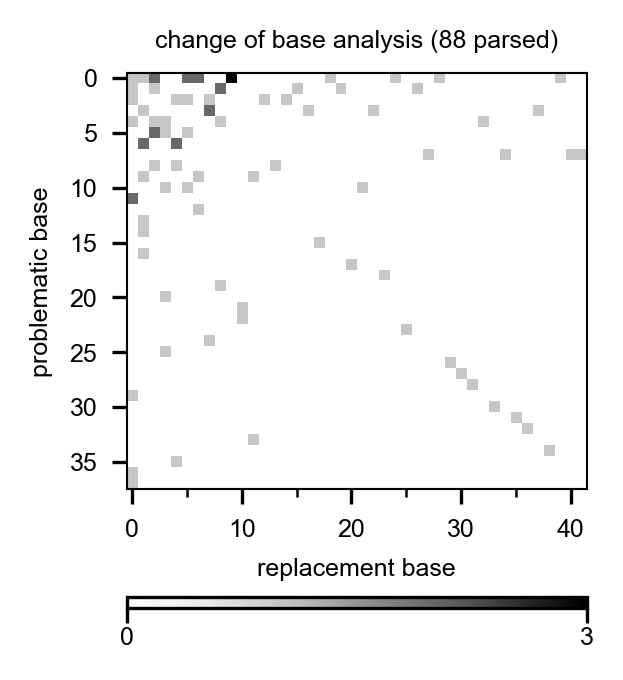

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

# fontsize 6, arial
plt.rc('font', size=6)
plt.rc('font', family='Arial')

# 1) Joint counts
pair_counts = Counter(final_pairs)
problem_keys = sorted(ps_check.keys(), key=lambda k: ps_check[k], reverse=True)
print(problem_keys)
replacement_keys = sorted(rs_check.keys(), key=lambda k: rs_check[k], reverse=True)
data = np.zeros((len(problem_keys), len(replacement_keys)), dtype=int)

for (ps, rs), count in pair_counts.items():
    if ps in problem_keys and rs in replacement_keys:
        i = problem_keys.index(ps)
        j = replacement_keys.index(rs)
        data[i, j] = count

heat_df = pd.DataFrame(data, index=problem_keys, columns=replacement_keys)

fig, ax = plt.subplots(figsize=(2.06, 2.7), dpi=300)

im = ax.imshow(heat_df.values, cmap="Greys", aspect="equal", interpolation="nearest")
ax.set_title("change of base analysis (88 parsed)", fontsize=6, fontfamily="Arial")
ax.set_xlabel("replacement base", fontsize=6, fontfamily="Arial")
ax.set_ylabel("problematic base", fontsize=6, fontfamily="Arial")

ax.set_xticks(np.arange(-0, len(replacement_keys), 5), minor=True)
ax.set_yticks(np.arange(-0, len(problem_keys), 5), minor=True)

# Frame
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color("black")

# # Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=1, location="bottom", pad=0.15, aspect=40)
cbar.ax.tick_params(labelsize=6, pad=1)
cbar.ax.set_xticks([0,3])

plt.tight_layout()
plt.savefig("figure4_baseheatmap.png", dpi=300, pad_inches=0, bbox_inches="tight")

In [ ]:
from rdkit import Chem

common_ungreen = {}
common_green = {}
for kk in green_score_outs:
    for nn in kk.problematic_compounds:
        if nn.smiles:
            mol = Chem.MolFromSmiles(nn.smiles)
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_ungreen[smiles] = common_ungreen.get(smiles, 0) + 1
        elif nn.name in base_smiles_map:
            if base_smiles_map[nn.name] == None:
                continue
            mol = Chem.MolFromSmiles(base_smiles_map[nn.name])
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_ungreen[smiles] = common_ungreen.get(smiles, 0) + 1
        elif nn.name in name_to_smiles:
            if name_to_smiles[nn.name] == None:
                continue
            mol = Chem.MolFromSmiles(name_to_smiles[nn.name])
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_ungreen[smiles] = common_ungreen.get(smiles, 0) + 1
        elif nn.name in smiles_map:
            if smiles_map[nn.name] == None:
                continue
            mol = Chem.MolFromSmiles(smiles_map[nn.name])
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_ungreen[smiles] = common_ungreen.get(smiles, 0) + 1
        else:
            print(nn.name)
    # print(kk)
    for nn in kk.replacement_compounds:
        if nn.smiles:
            mol = Chem.MolFromSmiles(nn.smiles)
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_green[smiles] = common_green.get(smiles, 0) + 1
        elif nn.name in base_smiles_map:
            if base_smiles_map[nn.name] == None:
                continue
            mol = Chem.MolFromSmiles(base_smiles_map[nn.name])
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_green[smiles] = common_green.get(smiles, 0) + 1
        elif nn.name in name_to_smiles:
            if name_to_smiles[nn.name] == None:
                continue
            mol = Chem.MolFromSmiles(name_to_smiles[nn.name])
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_green[smiles] = common_green.get(smiles, 0) + 1
        elif nn.name in smiles_map:
            if smiles_map[nn.name] == None:
                continue
            mol = Chem.MolFromSmiles(smiles_map[nn.name])
            if mol is None:
                continue
            smiles = Chem.MolToSmiles(mol)
            common_green[smiles] = common_green.get(smiles, 0) + 1
        elif nn.name in smiles_or_name_map:
            if smiles_or_name_map[nn.name] == None:
                continue
            try:
                mol = Chem.MolFromSmiles(smiles_or_name_map[nn.name])
                smiles = Chem.MolToSmiles(mol)
                common_green[smiles] = common_green.get(smiles, 0) + 1
            except:
                common_green[nn.name] = common_green.get(nn.name, 0) + 1
        else:
            print(nn.name)




In [ ]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Helper: Morgan fingerprint (bit vector → numpy array)
# -----------------------------------------------------------
def fp(smiles, n_bits=2048):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=n_bits)
    arr = np.zeros((n_bits,), dtype=np.int8)
    Chem.DataStructs.ConvertToNumpyArray(fp, arr)
    return arr

# -----------------------------------------------------------
# Build fingerprint matrices
# -----------------------------------------------------------
problem_smiles, problem_fps = [], []
solution_smiles, solution_fps = [], []

for ps,count in sorted_common_green:
    # skip None or unknowns
    try:
        mol = Chem.MolFromSmiles(ps)
        fps = AllChem.GetMorganFingerprintAsBitVect(mol, radius=4, nBits=2048)
        solution_smiles.append(ps)
        solution_fps.append(fps)
    except:
        continue
for ps,count in sorted_common_ungreen:
    # skip None or unknowns
    try:
        mol = Chem.MolFromSmiles(ps)
        fps = fp(ps)
        problem_smiles.append(ps)
        problem_fps.append(fps)
    except:
        continue
all_vecs = np.vstack([problem_fps, solution_fps])
# -----------------------------------------------------------
# PCA embedding
# -----------------------------------------------------------
pca = PCA(n_components=2)
embed_pca = pca.fit_transform(all_vecs)

N = len(problem_vecs)
pca_problem = embed_pca[:N]
pca_solution = embed_pca[N:]

# -----------------------------------------------------------
# UMAP embedding
# -----------------------------------------------------------
um = umap.UMAP(n_components=2, n_neighbors=4, min_dist=0.1)
embed_umap = um.fit_transform(all_vecs)

umap_problem = embed_umap[:N]
umap_solution = embed_umap[N:]

# -----------------------------------------------------------
# Plot function with direction arrows
# -----------------------------------------------------------


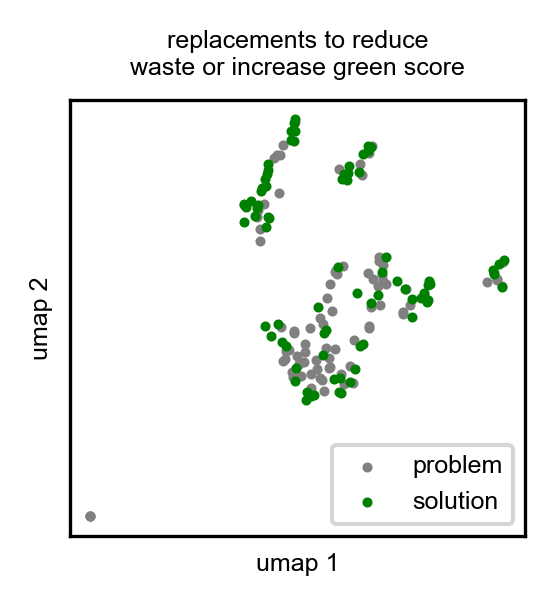

In [377]:
def plot_with_arrows(Xp, Xs, title):
    fig, ax = plt.subplots(figsize=(1.83, 2), dpi=300)

    # Problem points
    ax.scatter(Xp[:,0], Xp[:,1], c='grey', s=2, label='problem')

    # Solution points
    ax.scatter(Xs[:,0], Xs[:,1], c='green', s=2, label='solution')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=6)
    ax.legend()
    ax.set_xlabel("umap 1")
    ax.set_ylabel("umap 2")
    plt.tight_layout()
    plt.savefig(f"{title}.png", dpi=300, pad_inches=0.01, bbox_inches="tight")
    # plt.show()

# -----------------------------------------------------------
# Final plots
# -----------------------------------------------------------
# plot_with_arrows(pca_problem, pca_solution, "replacements to reduce waste or increase green score")

# "reagent_change_to_reduce_waste_or_increase_green_score"
plot_with_arrows(umap_problem, umap_solution, "replacements to reduce\nwaste or increase green score")